Setup complete. Fixed seed: 42
Found 143 PDF files in raw directory.


Extracting PDF text: 100%|██████████| 143/143 [02:01<00:00,  1.17it/s]



Successfully extracted text from 143 PDFs.
Raw data saved to: /Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_raw.csv
Computing extended raw text metrics...

=== RAW CORPUS OVERALL SUMMARY ===
Total Documents: 143
Total Raw Words (Tokens): 535,709
Total Characters: 3,809,735
Average Words per Document: 3746.22 (Std: 5645.99)
Average Lexical Diversity (Raw TTR): 0.3697

=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===
                               mean           std        min           50%  \
word_count              3746.216783   5645.991148  11.000000   2170.000000   
char_count             26641.503497  38888.869984  71.000000  16048.000000   
line_count               381.909091    552.485433   2.000000    232.000000   
unique_word_count       1074.727273    979.390204  11.000000    842.000000   
avg_word_length            7.117404      0.439699   6.201940      7.106764   
lexical_diversity_ttr    

/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


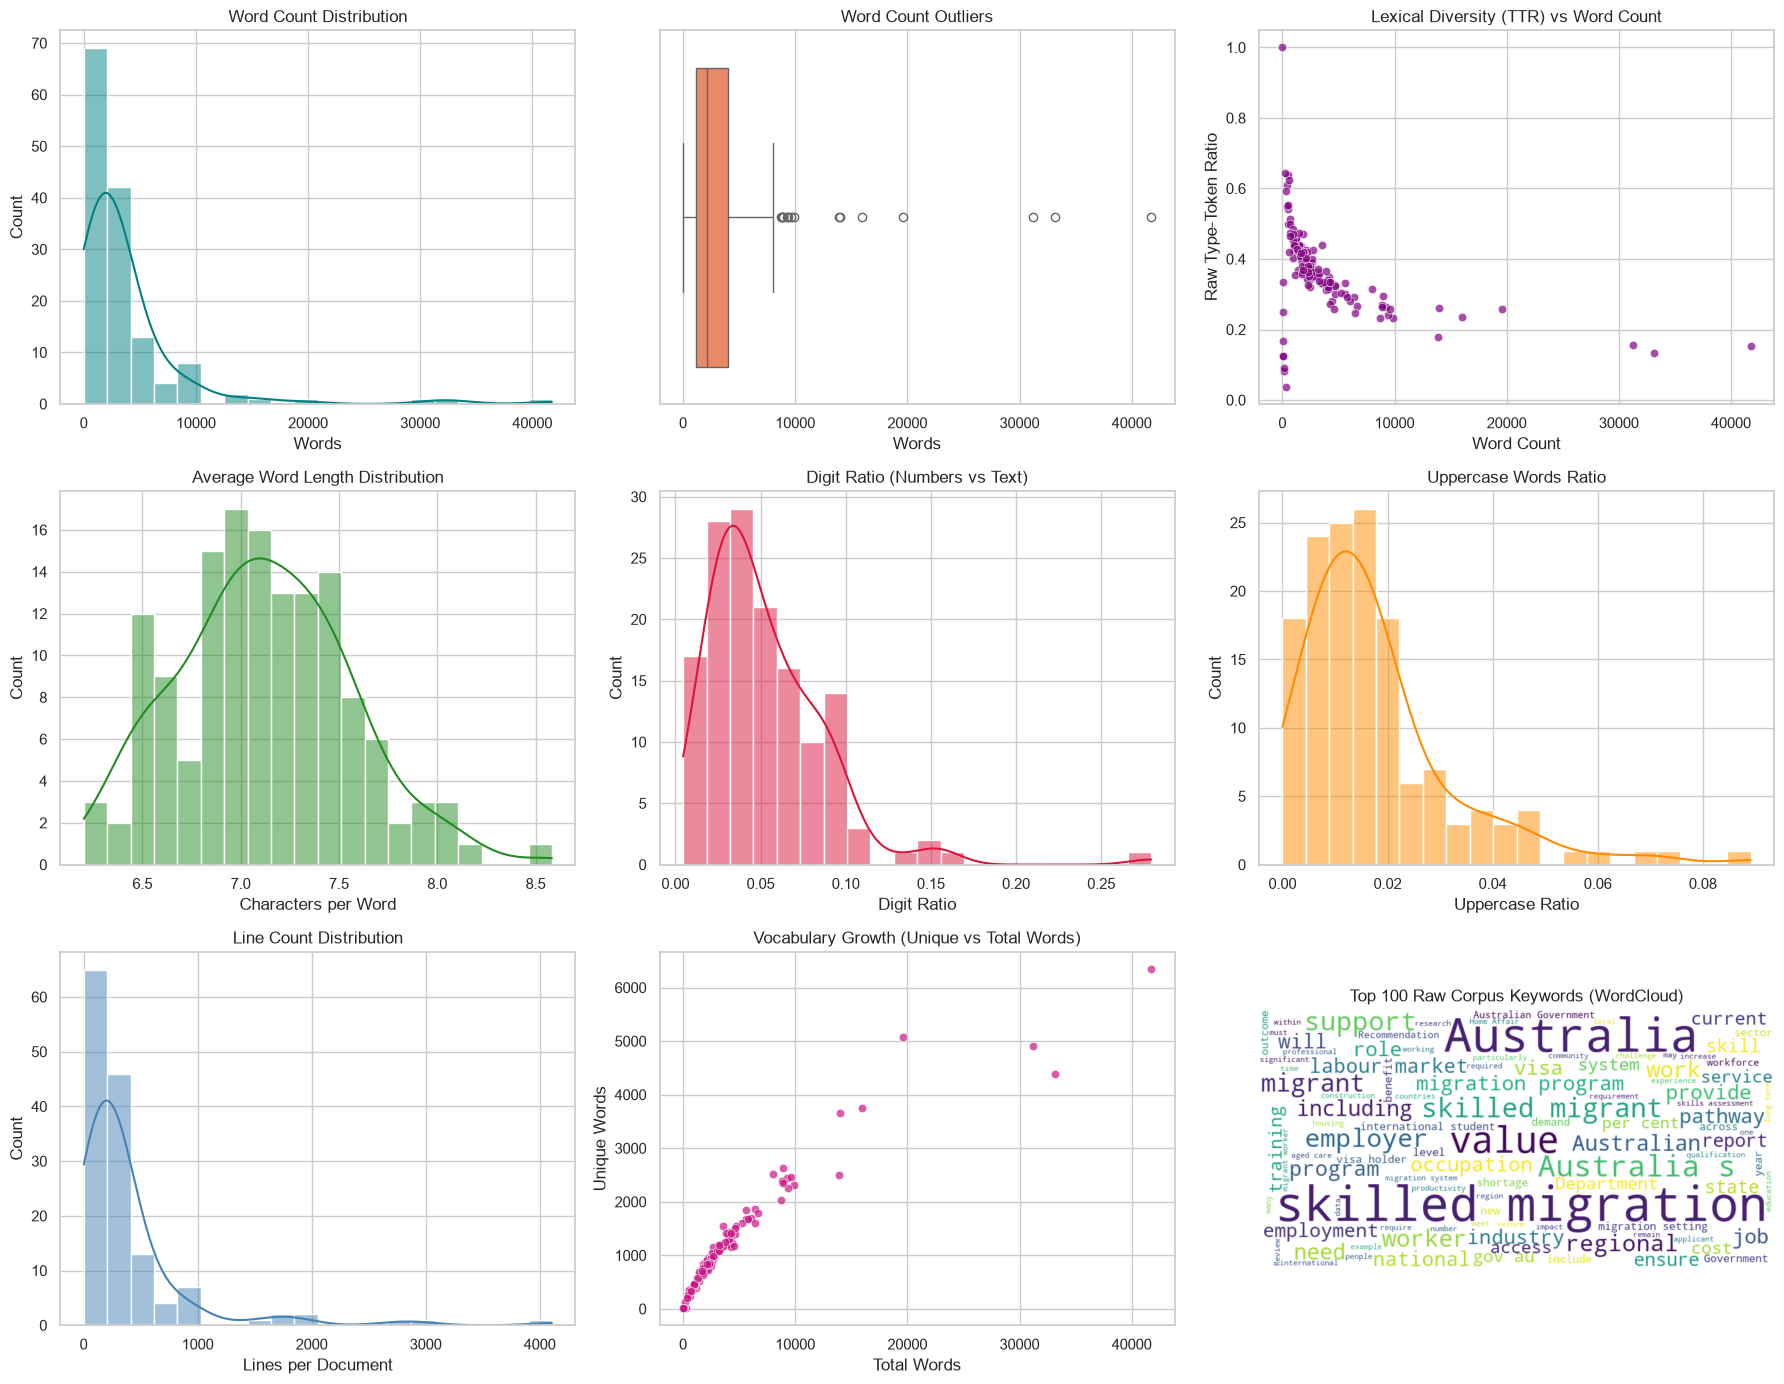

Boilerplate lines detected (appear in >=30% of docs): 82
  - in quiry into the value of skilled migration to australia 3
  - 4 | inquiry into the value of skilled migration to australia
  - inquiry into the value of skilled migration to australia - submission 4
  - into the value of skilled migration to
  - inquiry into the value of skilled migration in australia
  - inquiry into the value of skilled migra�on to australia
  - 3 | inquiry into the value of skilled migration to australia
  - inquiry into the value of skilled migration to australia - submission
  - . the role of skilled migration
  - inq uiry into the value of skilled migration to australia 10

Average % of words removed by URL/boilerplate stripping: 10.46%
(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)
Cleaning and lemmatizing text corpus...


Cleaning: 100%|██████████| 143/143 [00:15<00:00,  9.15it/s]


Text preprocessing complete!
CHECKPOINT 1: TEXT CLEANING QUALITY
Average % of words removed during cleaning: 44.66%
If this is above ~70-75%, the cleaning may be too aggressive.

--- Sample raw vs. clean text (first 2 documents) ---

[Document 0] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 106
Inquiry into the value of skilled migration to Australia
Submission 106
Who we are
The Federation of Ethnic Communities’ Council

[Document 0] CLEAN (first 200 chars):
federation ethnic community council fecca national peak body represent people culturally linguistically diverse cald community organisation across membership state territory regional ethnic community 

[Document 1] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 112
Inquiry into the value of
Skilled Migration to
Australia
Submission by the Australian Council of Trade Unions
ACTU Submission, D

[Document 1] CLEAN (first 200 chars):
value skille

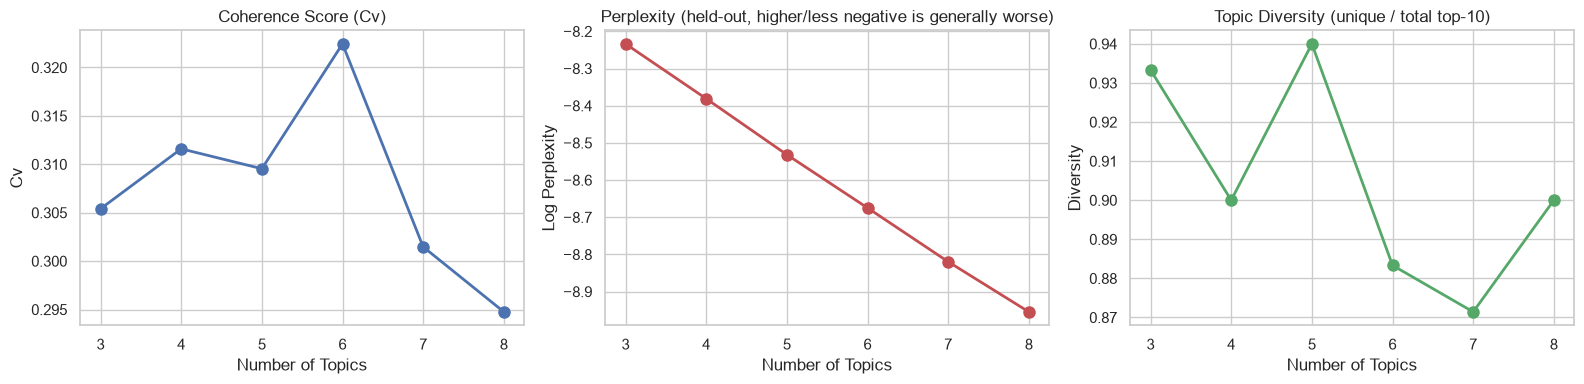


Optimal number of topics selected: 6
  Coherence (Cv): 0.3224
  Perplexity:     -8.6748
  Topic Diversity: 0.8833

=== TOP 10 KEYWORDS PER TOPIC (LDA - 6 TOPICS) ===

Topic 1: south, refugee, pilot, underutilisation, oecd, profession, course, state_nominate, skill_assessment, institute

Topic 2: nurse, skill_assessment, protection, apprentice, visa_holder, per_cent, subclass, obtain, union, exploitation

Topic 3: disability, university, multicultural, dairy, run, farm, retrieve, sustainability, meat, exploitation

Topic 4: dama, subclass, grant, engineer, subclass_visa, nsw, victoria, manager, welcome, provisional

Topic 5: small_business, exploitation, club, canada, young, per_cent, case_study, university, city, workshop

Topic 6: palm_scheme, palm_worker, figure, palm, tax, small_business, scheme, pacific, automotive, accommodation

=== SEMANTIC LABELS ASSIGNED ===
  Topic 1: south, refugee, pilot
  Topic 2: nurse, skill_assessment, protection
  Topic 3: disability, university, mult


Final processed dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_processed_v4.0.csv
Topic summary saved at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/topic_summary_v4.0.csv


In [1]:
"""
Skilled Migration Submissions — Topic Modeling Pipeline v4.0
==============================================================
Changes vs v3.1:
  1. FIX: Topic labels are no longer hardcoded/positional. v3.1 had a
     DEFAULT_TOPIC_LABELS dict written in advance that got applied by
     topic index, regardless of what keywords that index actually held
     in the current run. Since LDA topic ordering is not guaranteed to
     match between runs, this silently produced WRONG labels (e.g. a
     topic about "refugee, palm_scheme, tax" got labeled "Visa
     Applications & Skills Assessment"). v4.0 auto-generates a safe
     default label directly FROM each run's own top keywords, so the
     label can never drift out of sync with the topic's actual content.
     You can still override it manually after reading the keywords.
  2. Dictionary filtering tightened further: no_above 0.4 -> 0.35, to
     keep pushing dictionary size toward the healthy 500-2000 range.
  3. Everything else from v3.1 is kept as-is (it worked well):
     fuzzy boilerplate matching, title-phrase blocklist, n-gram length
     cap at trigrams, held-out perplexity, topic diversity metric.
Instructions:
  - Copy each block between # %% into a Jupyter cell, or run as a script
    with ipython (Jupyter) using %run. In VS Code, the # %% markers are
    recognized natively as Python Interactive cells.
  - Requires: pdfplumber, nltk, gensim, pyLDAvis, scikit-learn, matplotlib,
    seaborn, wordcloud, pandas, numpy, tqdm.
"""

# %% ------------------------------------------------------------------
# 0. IMPORTS, SEEDS, PATHS
# %% ------------------------------------------------------------------
import json
import os
import random
import re
from collections import Counter
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import pdfplumber

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import HTML, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Phrases
from gensim.models.phrases import Phraser
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# --- Reproducibility ---
# Fix seeds across every relevant generator so runs are comparable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Paths ---
RAW_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw"
)
PROCESSED_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed"
)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# --- Download required NLTK resources (includes the POS tagger) ---
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                  "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass  # resource names vary slightly across nltk versions; not critical if one fails

print("Setup complete. Fixed seed:", SEED)

# %% ------------------------------------------------------------------
# 1. EXTRACT TEXT FROM PDFs
# %% ------------------------------------------------------------------
def extract_pdf_text(filepath):
    """Extracts plain text from a PDF using pdfplumber."""
    full_text = []
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text.append(text)
        return "\n".join(full_text)
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")
        return None


pdf_files = list(RAW_DATA_PATH.glob("*.[pP][dD][fF]"))
print(f"Found {len(pdf_files)} PDF files in raw directory.")

records = []
for pdf_path in tqdm(pdf_files, desc="Extracting PDF text"):
    content = extract_pdf_text(pdf_path)
    if content:
        records.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": content,
        })

df = pd.DataFrame(records)
print(f"\nSuccessfully extracted text from {len(df)} PDFs.")

raw_csv_path = PROCESSED_DATA_PATH / "submissions_raw.csv"
df.to_csv(raw_csv_path, index=False)
print(f"Raw data saved to: {raw_csv_path}")

# %% ------------------------------------------------------------------
# 2. RAW TEXT STATISTICS AND VISUALIZATION
# %% ------------------------------------------------------------------
print("Computing extended raw text metrics...")

df["char_count"] = df["texto_raw"].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df["word_count"] = df["texto_raw"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df["line_count"] = df["texto_raw"].apply(lambda x: len(str(x).splitlines()) if pd.notna(x) else 0)

df["unique_word_count"] = df["texto_raw"].apply(
    lambda x: len(set(str(x).lower().split())) if pd.notna(x) else 0
)
df["avg_word_length"] = df.apply(
    lambda row: row["char_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)
df["lexical_diversity_ttr"] = df.apply(
    lambda row: row["unique_word_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)

df["uppercase_word_count"] = df["texto_raw"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) if pd.notna(x) else 0
)
df["digit_count"] = df["texto_raw"].apply(lambda x: len(re.findall(r"\d+", str(x))) if pd.notna(x) else 0)
df["punctuation_count"] = df["texto_raw"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x))) if pd.notna(x) else 0
)

df["digit_ratio"] = df["digit_count"] / df["word_count"].replace(0, 1)
df["uppercase_ratio"] = df["uppercase_word_count"] / df["word_count"].replace(0, 1)

print("\n=== RAW CORPUS OVERALL SUMMARY ===")
print(f"Total Documents: {len(df):,}")
print(f"Total Raw Words (Tokens): {df['word_count'].sum():,}")
print(f"Total Characters: {df['char_count'].sum():,}")
print(f"Average Words per Document: {df['word_count'].mean():.2f} (Std: {df['word_count'].std():.2f})")
print(f"Average Lexical Diversity (Raw TTR): {df['lexical_diversity_ttr'].mean():.4f}")

print("\n=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===")
metrics_to_show = [
    "word_count", "char_count", "line_count", "unique_word_count",
    "avg_word_length", "lexical_diversity_ttr", "digit_ratio", "uppercase_ratio",
]
print(df[metrics_to_show].describe().T[["mean", "std", "min", "50%", "max"]])

print("\n=== EXTREME DOCUMENTS IDENTIFICATION (diagnostic only, real filtering happens later) ===")
short_docs = df[df["word_count"] < 100][["archivo", "word_count", "char_count"]]
print(f"Documents with fewer than 100 words: {len(short_docs)}")
if len(short_docs) > 0:
    print(short_docs.head())

high_digit_docs = df[df["digit_ratio"] > 0.1][["archivo", "word_count", "digit_ratio"]]
print(f"\nDocuments with >10% digits (potential data tables): {len(high_digit_docs)}")
if len(high_digit_docs) > 0:
    print(high_digit_docs.head())

# --- 3x3 visualization panel ---
print("\nGenerating extended visualization panel including WordCloud...")
all_text = " ".join(df["texto_raw"].dropna().tolist())
custom_wc_stopwords = set(STOPWORDS).union({
    "http", "https", "www", "com", "pdf", "page", "subclass", "submission",
    "inquiry", "committee",
})

wc = WordCloud(
    width=800, height=400, background_color="white",
    stopwords=custom_wc_stopwords, max_words=100, colormap="viridis", random_state=SEED,
).generate(all_text)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df["word_count"], kde=True, ax=axes[0, 0], color="teal", bins=20)
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].set_xlabel("Words")

sns.boxplot(x=df["word_count"], ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Word Count Outliers")
axes[0, 1].set_xlabel("Words")

sns.scatterplot(data=df, x="word_count", y="lexical_diversity_ttr", ax=axes[0, 2], alpha=0.7, color="purple")
axes[0, 2].set_title("Lexical Diversity (TTR) vs Word Count")
axes[0, 2].set_xlabel("Word Count")
axes[0, 2].set_ylabel("Raw Type-Token Ratio")

sns.histplot(df["avg_word_length"], kde=True, ax=axes[1, 0], color="forestgreen", bins=20)
axes[1, 0].set_title("Average Word Length Distribution")
axes[1, 0].set_xlabel("Characters per Word")

sns.histplot(df["digit_ratio"], kde=True, ax=axes[1, 1], color="crimson", bins=20)
axes[1, 1].set_title("Digit Ratio (Numbers vs Text)")
axes[1, 1].set_xlabel("Digit Ratio")

sns.histplot(df["uppercase_ratio"], kde=True, ax=axes[1, 2], color="darkorange", bins=20)
axes[1, 2].set_title("Uppercase Words Ratio")
axes[1, 2].set_xlabel("Uppercase Ratio")

sns.histplot(df["line_count"], kde=True, ax=axes[2, 0], color="steelblue", bins=20)
axes[2, 0].set_title("Line Count Distribution")
axes[2, 0].set_xlabel("Lines per Document")

sns.scatterplot(data=df, x="word_count", y="unique_word_count", ax=axes[2, 1], color="mediumvioletred", alpha=0.7)
axes[2, 1].set_title("Vocabulary Growth (Unique vs Total Words)")
axes[2, 1].set_xlabel("Total Words")
axes[2, 1].set_ylabel("Unique Words")

axes[2, 2].imshow(wc, interpolation="bilinear")
axes[2, 2].axis("off")
axes[2, 2].set_title("Top 100 Raw Corpus Keywords (WordCloud)")

plt.tight_layout()
plt.show()

# %% ------------------------------------------------------------------
# 3. URL / EMAIL / BOILERPLATE REMOVAL (fuzzy matching)
# %% ------------------------------------------------------------------
# Strip URLs and email addresses BEFORE symbol stripping, otherwise
# something like "unionsnsw.org.au" gets shattered into "unionsnsw org au"
# by the later regex, and the phrase detector glues it back together into
# a meaningless token like "unionsnsw_org".
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+|\S+\.(?:com|org|gov|edu|au|net)\.?\S*)", re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\S+@\S+\.\S+")


def strip_urls_and_emails(text):
    if not isinstance(text, str):
        return text
    text = EMAIL_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return text


def normalize_line(line):
    """Normalize a line for comparison: lowercase, collapse whitespace."""
    return re.sub(r"\s+", " ", line.strip().lower())


def find_boilerplate_lines(texts, min_doc_fraction=0.3, min_len=15, fuzzy_threshold=0.88):
    """
    Finds lines that appear in at least min_doc_fraction of documents.
    Uses exact matching first, then a number-agnostic pass (so
    "4 | inquiry into..." and "11 | inquiry into..." both collapse to the
    same underlying boilerplate line), then fuzzy matching on top of that
    to catch small wording variations (curly apostrophes, punctuation,
    minor rephrasing of the same header/title).
    """
    n_docs = len(texts)
    normalized_lines_per_doc = []
    for text in texts:
        if not isinstance(text, str):
            normalized_lines_per_doc.append(set())
            continue
        lines = {normalize_line(l) for l in text.splitlines() if len(l.strip()) >= min_len}
        # Number-agnostic version catches "Submission NNN" / page-number variants
        number_agnostic = set()
        for line in lines:
            ag = re.sub(r"\d+", "", line).strip()
            if len(ag) >= min_len:
                number_agnostic.add(ag)
        lines.update(number_agnostic)
        normalized_lines_per_doc.append(lines)

    line_doc_counts = Counter()
    for lines in normalized_lines_per_doc:
        for line in lines:
            line_doc_counts[line] += 1
    threshold = max(2, int(n_docs * min_doc_fraction))
    boilerplate = {line for line, count in line_doc_counts.items() if count >= threshold}

    # Fuzzy expansion: any line similar enough to an existing boilerplate
    # line is added too, so remove_boilerplate catches near-duplicates.
    for lines in normalized_lines_per_doc:
        for line in lines:
            if line in boilerplate:
                continue
            for bp in boilerplate:
                if SequenceMatcher(None, line, bp).ratio() >= fuzzy_threshold:
                    boilerplate.add(line)
                    break
    return boilerplate


def remove_boilerplate(text, boilerplate_set, fuzzy_threshold=0.88):
    if not isinstance(text, str):
        return text
    kept_lines = []
    for raw_line in text.splitlines():
        norm = normalize_line(raw_line)
        if norm in boilerplate_set:
            continue
        is_bp = False
        for bp in boilerplate_set:
            if SequenceMatcher(None, norm, bp).ratio() >= fuzzy_threshold:
                is_bp = True
                break
        if not is_bp:
            kept_lines.append(raw_line)
    return "\n".join(kept_lines)


df["texto_sin_urls"] = df["texto_raw"].apply(strip_urls_and_emails)

boilerplate_lines = find_boilerplate_lines(df["texto_sin_urls"].tolist(), min_doc_fraction=0.3)
print(f"Boilerplate lines detected (appear in >=30% of docs): {len(boilerplate_lines)}")
for line in list(boilerplate_lines)[:10]:
    print("  -", line[:100])

df["texto_sin_boilerplate"] = df["texto_sin_urls"].apply(lambda x: remove_boilerplate(x, boilerplate_lines))

# Also strip loose "Submission N" mentions that don't form a full repeated line.
df["texto_sin_boilerplate"] = df["texto_sin_boilerplate"].apply(
    lambda x: re.sub(r"\bsubmission\s*\d+\b", " ", str(x), flags=re.IGNORECASE) if pd.notna(x) else x
)

removed_word_pct = (
    (df["texto_raw"].str.split().str.len() - df["texto_sin_boilerplate"].str.split().str.len())
    / df["texto_raw"].str.split().str.len().replace(0, 1)
) * 100
print(f"\nAverage % of words removed by URL/boilerplate stripping: {removed_word_pct.mean():.2f}%")
print("(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)")

# %% ------------------------------------------------------------------
# 4. CLEANING AND LEMMATIZATION
# %% ------------------------------------------------------------------
stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "sub", "submission", "inquiry", "committee", "australia", "australian",
    "parliament", "parliamentary", "page", "pdf", "accordance", "attached",
    "http", "https", "www", "com",
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# Small dictionary of common English contractions (avoids "don't" -> "don t"
# -> a meaningless "don" token surviving cleaning).
CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}


def expand_contractions(text):
    text = text.replace("’", "'")  # normalize curly apostrophe to straight
    for pattern, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(pattern) + r"\b", expansion, text)
    return text


def get_wordnet_pos(treebank_tag):
    """Maps NLTK POS tags to the tags WordNetLemmatizer expects, so verbs
    and adjectives get lemmatized correctly (not just nouns)."""
    if treebank_tag.startswith("J"):
        return "a"  # adjective
    elif treebank_tag.startswith("V"):
        return "v"  # verb
    elif treebank_tag.startswith("R"):
        return "r"  # adverb
    else:
        return "n"  # noun (default)


def preprocess_and_lemmatize(text):
    """
    Cleans raw text (already stripped of URLs/boilerplate):
    - Expands contractions
    - Lowercases
    - Removes numbers, punctuation, and non-alphabetic symbols
    - Tokenizes
    - Lemmatizes using real POS tagging (verbs, adjectives, nouns)
    - Removes stopwords and tokens of length <= 2
    """
    if not isinstance(text, str):
        return ""

    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    clean_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(clean_tokens)


print("Cleaning and lemmatizing text corpus...")
tqdm.pandas(desc="Cleaning")
df["texto_limpio"] = df["texto_sin_boilerplate"].progress_apply(preprocess_and_lemmatize)
print("Text preprocessing complete!")

df["clean_word_count"] = df["texto_limpio"].apply(lambda x: len(x.split()))
df["words_removed_%"] = ((df["word_count"] - df["clean_word_count"]) / df["word_count"]) * 100

# %% ------------------------------------------------------------------
# CHECKPOINT 1: TEXT CLEANING QUALITY
# %% ------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 1: TEXT CLEANING QUALITY")
print("=" * 70)
print(f"Average % of words removed during cleaning: {df['words_removed_%'].mean():.2f}%")
print("If this is above ~70-75%, the cleaning may be too aggressive.\n")

print("--- Sample raw vs. clean text (first 2 documents) ---")
for i in range(min(2, len(df))):
    print(f"\n[Document {i}] RAW (first 200 chars):")
    print(str(df["texto_raw"].iloc[i])[:200])
    print(f"\n[Document {i}] CLEAN (first 200 chars):")
    print(str(df["texto_limpio"].iloc[i])[:200])

all_words = " ".join(df["texto_limpio"].dropna()).split()
word_freq = pd.Series(Counter(all_words)).sort_values(ascending=False)
print("\n--- Top 50 most frequent words after cleaning ---")
print(word_freq.head(50))

ghost_tokens = [w for w in set(all_words) if w in {"don", "isn", "wasn", "aren", "doesn", "didn", "hasn", "wouldn"}]
print(f"\nGhost tokens still present (should be empty): {ghost_tokens}")

http_leftovers = [w for w in set(all_words) if w in {"http", "https", "www", "com"}]
print(f"URL-related leftovers (should be empty): {http_leftovers}")

# Documents that end up with zero clean tokens are suspicious on their own.
# In this corpus these turned out to be cover-page-only PDFs (the whole
# "document" is just the repeated inquiry title + submission number, with
# no actual submission content) — legitimate to drop, but always inspect
# the raw preview to confirm this isn't a PDF-extraction problem instead.
zero_token_docs = df[df["clean_word_count"] == 0][["archivo", "word_count", "clean_word_count"]]
print(f"\nDocuments with 0 clean tokens after cleaning: {len(zero_token_docs)}")
if len(zero_token_docs) > 0:
    print(zero_token_docs)
    print("\nRaw text preview of each (first 300 chars):")
    for _, row in zero_token_docs.iterrows():
        raw_preview = str(df.loc[df["archivo"] == row["archivo"], "texto_raw"].iloc[0])[:300]
        print(f"\n  [{row['archivo']}] word_count={row['word_count']}")
        print(f"  {raw_preview!r}")

# %% ------------------------------------------------------------------
# 5. BIGRAM / TRIGRAM DETECTION (npmi scoring + length cap)
# %% ------------------------------------------------------------------
# npmi scoring gives a bounded score (-1 to 1), which is much easier to
# threshold consistently than the default frequency-based scorer.
tokens_list_raw = [doc.split() for doc in df["texto_limpio"].dropna()]

bigram_model = Phrases(tokens_list_raw, min_count=5, threshold=0.5, scoring="npmi")
bigram_phraser = Phraser(bigram_model)

trigram_model = Phrases(bigram_phraser[tokens_list_raw], min_count=5, threshold=0.5, scoring="npmi")
trigram_phraser = Phraser(trigram_model)

tokens_list = [trigram_phraser[bigram_phraser[doc]] for doc in tokens_list_raw]

# Explicitly drop leftover fragments of the inquiry title that survive as
# bigrams/trigrams even after boilerplate line removal, since they're
# structural noise (the survey's own title), not topical content.
TITLE_PHRASE_BLOCKLIST = {
    "value_skilled_migration", "skilled_migration_australia",
    "value_skilled_migration_australia", "skilled_migration",
}


def drop_blocklisted_phrases(doc_tokens, blocklist):
    return [t for t in doc_tokens if t not in blocklist]


tokens_list = [drop_blocklisted_phrases(doc, TITLE_PHRASE_BLOCKLIST) for doc in tokens_list]

# Cap n-gram length to trigrams (max 2 underscores). Longer chains are
# almost always noise (addresses, accidental concatenations).
MAX_UNDERSCORES = 2  # allows unigrams, bigrams, trigrams
tokens_list = [[t for t in doc if t.count("_") <= MAX_UNDERSCORES] for doc in tokens_list]

# %% ------------------------------------------------------------------
# CHECKPOINT 2: BIGRAM / TRIGRAM QUALITY
# %% ------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 2: BIGRAM / TRIGRAM QUALITY")
print("=" * 70)

all_tokens_flat = [tok for doc in tokens_list for tok in doc]
phrase_freq = pd.Series(Counter(t for t in all_tokens_flat if "_" in t)).sort_values(ascending=False)
print("--- Top 20 detected phrases ---")
print(phrase_freq.head(20))

long_chains = [p for p in phrase_freq.index if p.count("_") >= 3]
print(f"\nPhrases with 4+ words chained together (should be 0 now): {len(long_chains)}")
if long_chains:
    print(long_chains[:10])

print("\nRead through this list: phrases should look like real concepts")
print("(e.g. 'skill_shortage'), not generic grammar combos or long chains.")

# %% ------------------------------------------------------------------
# 6. DOCUMENT FILTERING (separate criteria: too short vs. too noisy)
# %% ------------------------------------------------------------------
MIN_CLEAN_WORDS = 50
MAX_DIGIT_RATIO = 0.25

df["is_too_short"] = df["clean_word_count"] < MIN_CLEAN_WORDS
df["is_too_numeric"] = df["digit_ratio"] > MAX_DIGIT_RATIO

mask_keep = ~(df["is_too_short"] | df["is_too_numeric"])

print("=" * 70)
print("CHECKPOINT 3: DOCUMENT FILTERING")
print("=" * 70)
print(f"Documents before filtering: {len(df)}")
print(f"Documents removed for being too short (<{MIN_CLEAN_WORDS} clean words): {df['is_too_short'].sum()}")
print(f"Documents removed for being too numeric (digit_ratio > {MAX_DIGIT_RATIO}): {df['is_too_numeric'].sum()}")
print(f"Documents after filtering: {mask_keep.sum()}")
print("If you removed more than ~20% of the corpus, double check that the")
print("removed documents are actually low-quality and not legitimate texts.\n")

removed_docs = df[~mask_keep][["archivo", "word_count", "clean_word_count", "digit_ratio"]]
print("--- Sample of removed documents ---")
print(removed_docs.head(10))

# Keep df_filtered and tokens_list aligned by index.
keep_indices = df.index[mask_keep].tolist()
df_filtered = df.loc[mask_keep].reset_index(drop=True)
tokens_list = [tokens_list[i] for i in keep_indices]

# %% ------------------------------------------------------------------
# 7. DICTIONARY AND CORPUS FOR GENSIM
# %% ------------------------------------------------------------------
print("Preparing dictionary and corpus for LDA...")

dictionary = corpora.Dictionary(tokens_list)
# FIX (v4.0): no_above tightened further (0.4 -> 0.35) to keep pushing
# dictionary size toward the healthy 500-2000 range for a corpus this size.
# no_below=5 -> a word must appear in at least 5 documents to be kept.
dictionary.filter_extremes(no_below=5, no_above=0.35)

corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f"Dictionary Size (Unique Tokens): {len(dictionary)}")
print(f"Total Processed Documents: {len(corpus)}")

# %% ------------------------------------------------------------------
# CHECKPOINT 4: DICTIONARY QUALITY
# %% ------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 4: DICTIONARY QUALITY")
print("=" * 70)
print(f"Dictionary size: {len(dictionary)} unique tokens for {len(corpus)} documents")
print("Rule of thumb for ~100-150 docs: 500-2000 tokens.")
print("If still above 2500, consider tightening no_above further or raising")
print("min_count in the Phrases models (step 5).\n")

sample_size = min(30, len(dictionary))
sample_words = random.sample(list(dictionary.token2id.keys()), sample_size)
print(f"--- Random sample of {sample_size} dictionary words ---")
print(sample_words)
print("\nCheck: do these look like real, meaningful words/phrases?")
print("If you see fragments, garbage, or long chained phrases, revisit steps 4-5.")

# %% ------------------------------------------------------------------
# 8. TRAIN / TEST SPLIT FOR UNBIASED PERPLEXITY
# %% ------------------------------------------------------------------
# Hold out 20% of documents for perplexity so the metric isn't
# optimistically biased by having seen the training data.
corpus_indices = list(range(len(corpus)))
train_idx, test_idx = train_test_split(corpus_indices, test_size=0.2, random_state=SEED)
train_corpus = [corpus[i] for i in train_idx]
test_corpus = [corpus[i] for i in test_idx]
train_tokens = [tokens_list[i] for i in train_idx]
print(f"Train documents: {len(train_corpus)} | Test documents: {len(test_corpus)}")

# %% ------------------------------------------------------------------
# 9. LDA TRAINING + OPTIMAL NUMBER OF TOPICS SEARCH
# %% ------------------------------------------------------------------
print("\nEvaluating LDA models across topic range...")
topic_range = range(3, 9)
results = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=SEED,
        passes=15,
        iterations=400,
        alpha="auto",
        eta="auto",
    )

    # Coherence on TRAIN texts (standard practice for c_v).
    coherence_model = CoherenceModel(
        model=lda_model, texts=train_tokens, dictionary=dictionary, coherence="c_v"
    )
    coherence = coherence_model.get_coherence()

    # Perplexity on the HELD-OUT test corpus (unbiased).
    perplexity = lda_model.log_perplexity(test_corpus)

    # Topic Diversity: fraction of unique words among top-10 across all topics.
    all_topic_words = []
    for t in range(num_topics):
        all_topic_words.extend([w for w, _ in lda_model.show_topic(t, topn=10)])
    topic_diversity = len(set(all_topic_words)) / len(all_topic_words) if all_topic_words else 0

    results.append({
        "num_topics": num_topics,
        "coherence_cv": coherence,
        "perplexity": perplexity,
        "topic_diversity": topic_diversity,
    })
    lda_models[num_topics] = lda_model

    print(f"Topics: {num_topics} | Coherence: {coherence:.4f} | Perplexity: {perplexity:.4f} | Diversity: {topic_diversity:.4f}")

results_df = pd.DataFrame(results)
print("\n=== COMPARISON TABLE ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(results_df["num_topics"], results_df["coherence_cv"], "bo-", linewidth=2, markersize=8)
axes[0].set_title("Coherence Score (Cv)")
axes[0].set_xlabel("Number of Topics")
axes[0].set_ylabel("Cv")
axes[0].grid(True)

axes[1].plot(results_df["num_topics"], results_df["perplexity"], "ro-", linewidth=2, markersize=8)
axes[1].set_title("Perplexity (held-out, higher/less negative is generally worse)")
axes[1].set_xlabel("Number of Topics")
axes[1].set_ylabel("Log Perplexity")
axes[1].grid(True)

axes[2].plot(results_df["num_topics"], results_df["topic_diversity"], "go-", linewidth=2, markersize=8)
axes[2].set_title("Topic Diversity (unique / total top-10)")
axes[2].set_xlabel("Number of Topics")
axes[2].set_ylabel("Diversity")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Selection strategy: prioritize coherence, but flag if diversity drops.
best_coherence_idx = results_df["coherence_cv"].idxmax()
optimal_num_topics = int(results_df.loc[best_coherence_idx, "num_topics"])
best_lda_model = lda_models[optimal_num_topics]

print(f"\nOptimal number of topics selected: {optimal_num_topics}")
print(f"  Coherence (Cv): {results_df.loc[best_coherence_idx, 'coherence_cv']:.4f}")
print(f"  Perplexity:     {results_df.loc[best_coherence_idx, 'perplexity']:.4f}")
print(f"  Topic Diversity: {results_df.loc[best_coherence_idx, 'topic_diversity']:.4f}")
if results_df.loc[best_coherence_idx, "topic_diversity"] < 0.6:
    print("\nWARNING: Topic diversity is below 0.6. Topics likely share many top words.")
    print("Consider adding domain-specific stopwords or raising no_above further.")

# %% ------------------------------------------------------------------
# 10. TOPIC INTERPRETATION & SEMANTIC LABELS
# %% ------------------------------------------------------------------
# FIX (v4.0): the previous version used a DEFAULT_TOPIC_LABELS dict with
# text written in advance and applied by topic INDEX. Because LDA topic
# ordering is not guaranteed to be stable across runs (different
# preprocessing, different num_topics, even different environments), this
# silently produced labels that didn't match the actual keywords of that
# index in the current run (e.g. a topic about refugees/PALM getting
# labeled "Visa Applications & Skills Assessment").
#
# The fix: the default label is now GENERATED from each run's own top
# keywords, so it can never be out of sync with what the topic actually
# contains. You can still edit TOPIC_LABEL_OVERRIDES below after reading
# the printed keywords, for a more polished/human label — but even if you
# don't, the auto-generated label will always be accurate to the content.
print(f"\n=== TOP 10 KEYWORDS PER TOPIC (LDA - {optimal_num_topics} TOPICS) ===")
topic_keywords = {}
for topic_id in range(optimal_num_topics):
    terms = best_lda_model.show_topic(topic_id, topn=10)
    words = [word for word, weight in terms]
    topic_keywords[topic_id] = words
    print(f"\nTopic {topic_id + 1}: {', '.join(words)}")

# Auto-generated label: built from each topic's own top 3 keywords, so it
# is guaranteed to match the content of that specific run.
auto_labels = {
    tid: f"Topic {tid + 1}: {', '.join(words[:3])}"
    for tid, words in topic_keywords.items()
}

# OPTIONAL: after reading the keywords printed above, you can give any
# topic a more polished human-readable name here. Only fill in the topics
# that exist in THIS run (0 to optimal_num_topics - 1). Anything not
# overridden here falls back to the safe auto-generated label above.
TOPIC_LABEL_OVERRIDES = {
    # Example (edit after inspecting the keywords for this run):
    # 0: "Healthcare & Trades Occupation Shortages",
    # 3: "Refugees & the PALM Scheme",
}

topic_labels = {
    tid: TOPIC_LABEL_OVERRIDES.get(tid, auto_labels[tid])
    for tid in range(optimal_num_topics)
}

print("\n=== SEMANTIC LABELS ASSIGNED ===")
for tid, label in topic_labels.items():
    print(f"  {label}")
print("\nTip: edit TOPIC_LABEL_OVERRIDES above with your own interpretation")
print("after reading the keywords, then re-run this cell (no need to retrain).")

# %% ------------------------------------------------------------------
# CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION
# %% ------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION")
print("=" * 70)
print("Read the topic keywords above. Do they look like coherent, real-world")
print("concepts? Or generic words like 'would', 'also', 'one', 'said'?")
print("If you see generic filler words dominating a topic, add them to")
print("custom_stopwords in step 4 and re-run from there.\n")

dominant_topics = []
topic_mixtures = []
for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(bow, minimum_probability=0)
    probs_dict = dict(topic_probs)
    full_probs = [probs_dict.get(t, 0.0) for t in range(optimal_num_topics)]
    topic_mixtures.append(full_probs)
    dominant = np.argmax(full_probs)
    dominant_topics.append(dominant)

df_filtered["dominant_topic"] = dominant_topics
df_filtered["topic_mixture"] = topic_mixtures

topic_distribution = df_filtered["dominant_topic"].value_counts().sort_index()
print("--- Number of documents per dominant topic ---")
for tid, count in topic_distribution.items():
    label = topic_labels.get(tid, f"Topic {tid + 1}")
    print(f"  {label}: {count} docs")

print("\nIf one topic absorbs the vast majority of documents, the model")
print("likely isn't finding meaningful structure (try fewer topics, or")
print("revisit the cleaning/filtering/phrase-detection steps).")

clear_assignments = sum(1 for probs in topic_mixtures if max(probs) > 0.5)
print(f"\nDocuments with a clear dominant topic (>50% probability): {clear_assignments}/{len(corpus)} ({100*clear_assignments/len(corpus):.1f}%)")
print("Low values (<60%) suggest topics are too mixed or the corpus is too heterogeneous.")

# %% ------------------------------------------------------------------
# CHECKPOINT 6: HUMAN VALIDATION SAMPLE
# %% ------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 6: HUMAN VALIDATION SAMPLE")
print("=" * 70)
print("INSTRUCTIONS: For each sample document, judge:")
print("  (a) Does the dominant topic make sense given the raw text?")
print("  (b) Are the top keywords of that topic present in the document?")
print("  (c) Rate: 1=Wrong, 2=Partially related, 3=Clear match\n")

sample_docs = df_filtered.sample(min(5, len(df_filtered)), random_state=SEED)
for _, row in sample_docs.iterrows():
    tid = row["dominant_topic"]
    label = topic_labels.get(tid, f"Topic {tid + 1}")
    keywords = ", ".join(topic_keywords[tid][:5])
    print(f"\nDocument: {row['archivo']}")
    print(f"Assigned: {label}")
    print(f"Top keywords: {keywords}")
    print(f"Raw preview: {str(row['texto_raw'])[:200]}...")
    print("-" * 50)

# %% ------------------------------------------------------------------
# 11. INTERACTIVE VISUALIZATION (pyLDAvis)
# %% ------------------------------------------------------------------
print("\nGenerating interactive pyLDAvis visualization...")

vis_data = gensimvis.prepare(best_lda_model, corpus, dictionary, sort_topics=False)


def clean_for_json(obj):
    if isinstance(obj, (np.complex128, np.complex64, complex)):
        return float(obj.real)
    if isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.map(clean_for_json)
    if isinstance(obj, pd.Series):
        return obj.map(clean_for_json)
    return obj


cleaned_vis_data = pyLDAvis.PreparedData(
    topic_coordinates=clean_for_json(vis_data.topic_coordinates),
    topic_info=clean_for_json(vis_data.topic_info),
    token_table=clean_for_json(vis_data.token_table),
    R=vis_data.R,
    lambda_step=vis_data.lambda_step,
    plot_opts=vis_data.plot_opts,
    topic_order=vis_data.topic_order,
)

html_string = pyLDAvis.prepared_data_to_html(cleaned_vis_data)

css_override = """
<style>
    circle.bubble {
        fill-opacity: 0.6 !important;
        stroke: #333 !important;
        stroke-width: 1px !important;
    }
    circle.bubble:hover {
        fill-opacity: 0.9 !important;
        stroke-width: 2px !important;
    }
</style>
"""
html_string_fixed = css_override + html_string

html_output_path = PROCESSED_DATA_PATH / "lda_visualization_v4.0.html"
with open(html_output_path, "w", encoding="utf-8") as f:
    f.write(html_string_fixed)

print(f"Interactive LDA visualization saved successfully at:\n{html_output_path}")
display(HTML(html_string_fixed))

# %% ------------------------------------------------------------------
# 12. SAVE PROCESSED DATASET (includes topic metadata)
# %% ------------------------------------------------------------------
processed_csv_path = PROCESSED_DATA_PATH / "submissions_processed_v4.0.csv"
df_filtered["topic_label"] = df_filtered["dominant_topic"].map(topic_labels)
df_filtered.to_csv(processed_csv_path, index=False)
print(f"\nFinal processed dataset saved successfully at:\n{processed_csv_path}")

# Also save a lightweight summary CSV.
summary_records = []
for tid in range(optimal_num_topics):
    summary_records.append({
        "topic_id": tid + 1,
        "topic_label": topic_labels.get(tid, f"Topic {tid + 1}"),
        "top_keywords": ", ".join(topic_keywords[tid]),
        "doc_count": int(topic_distribution.get(tid, 0)),
    })
summary_df = pd.DataFrame(summary_records)
summary_path = PROCESSED_DATA_PATH / "topic_summary_v4.0.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Topic summary saved at:\n{summary_path}")